<a href="https://colab.research.google.com/github/DurkadeviGanesanMCA/State-wise-GST-Revenue-Analysis-in-India-Using-Python/blob/main/State_wise_GST_Revenue_Analysis_in_India_Using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ***State-wise-GST-Revenue-Analysis-in-India-Using-Python***

### **Business Objective**

Analyze GST tax collection data across Indian states and tax components to identify revenue trends, evaluate state-wise tax performance, and provide data-driven recommendations that support revenue planning, tax policy decisions, and improved tax compliance.

### **Analytical Objectives**

*   Compare GST collections across states and Union Territories.

*   Analyze trends in GST collection by month and year.

*   Identify the contribution of CGST, SGST, IGST, and Cess to total GST revenue.

*   Determine the top and bottom revenue-contributing states.

*   Analyze year-over-year (YoY) and month-over-month (MoM) growth in GST collections.

*   Identify seasonal patterns and revenue fluctuations.

*   Detect anomalies or unusually high/low GST collections.




### **Dataset Schema**

| **Column Name** | **Data Type**                               | **Description**                                                                  |
| --------------- | ------------------------------------------- | -------------------------------------------------------------------------------- |
| **id**          | Integer (`int64`)                           | Unique identifier for each GST collection record.                                |
| **date**        |  `object` *(convert to `datetime`)* | Date of GST collection. Used for monthly and yearly trend analysis.              |
| **state_name**  |  (`object`)                           | Name of the Indian State or Union Territory.                                     |
| **state_code**  |  (`int64`)                           | Official state or Union Territory code.                                          |
| **cgst**        |  (`float64`)                         | Central Goods and Services Tax (CGST) collected.                                 |
| **sgst**        |  (`float64`)                         | State Goods and Services Tax (SGST) collected.                                   |
| **igst**        |  (`float64`)                         | Integrated Goods and Services Tax (IGST) collected from interstate transactions. |
| **cess**        |  (`float64`)                         | GST Compensation Cess collected on specified goods and services.                 |


### **Tools And Technologies**
| **Category**                  | **Tool / Technology**      | **Purpose**                                                          |
| ----------------------------- | -------------------------- | -------------------------------------------------------------------- |
| **Programming Language**      | Python                     | Data analysis, data cleaning, feature engineering, and visualization |
| **Data Processing**           | Pandas                     | Data manipulation and analysis                                       |
| **Numerical Computing**       | NumPy                      | Numerical operations and calculations                                |
| **Data Visualization**        | Matplotlib                 | Static charts and graphs                                             |
| **Interactive Visualization** | Plotly *(Optional)*        | Interactive dashboards and                  |
| **Development Environment**   | Google Colab | Code development and analysis                                        |
| **Version Control**           | Git                        | Track project changes                                                |
| **Repository Hosting**        | GitHub                     | Store code, documentation, and project files                         |
| **Dataset Format**            | CSV                        | Source data format                                                   |
| **Documentation**             | Markdown (README.md)       | Project documentation and GitHub presentation                        |


### **Python Libraries Used**
| **Library**           | **Purpose**                              |
| --------------------- | ---------------------------------------- |
| `pandas`              | Data loading, cleaning, and manipulation |
| `numpy`               | Mathematical and numerical computations  |
| `matplotlib`          | Data visualization                       |
| `plotly` *(Optional)* | Interactive charts      |
| `Seaborn`              | data visualization library built on top of Matplotlib |

In [56]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore")

## **Data Ingestion**


In [57]:
#Data Loded From Github

url = "https://raw.githubusercontent.com/DurkadeviGanesanMCA/State-wise-GST-Revenue-Analysis-in-India-Using-Python/main/tax-collection-on-gst-portal.csv"


In [58]:
#Csv file is converted to datafarme with pandas

df = pd.read_csv(url)

In [59]:
df

,id,date,state_name,state_code,cgst,sgst,igst,cess
0,0,2017-07-01,Andaman And Nicobar Islands,35,0.00,0.00,0.00,0.00
1,1,2017-07-01,Andhra Pradesh,28,2.60,2.59,4.32,0.00
2,2,2017-07-01,Arunachal Pradesh,12,0.00,0.00,0.00,0.00
3,3,2017-07-01,Assam,18,0.02,0.02,0.21,0.07
4,4,2017-07-01,Bihar,10,0.02,0.02,0.47,0.04
...,...,...,...,...,...,...,...,...
3565,3565,2026-01-01,The Dadra And Nagar Haveli And Daman And Diu,38,53.07,67.63,306.58,427.28
3566,3566,2026-01-01,Tripura,16,41.25,55.09,16.78,113.12
3567,3567,2026-01-01,Uttar Pradesh,9,2294.85,3003.33,3080.54,8378.72
3568,3568,2026-01-01,Uttarakhand,5,311.86,470.40,687.53,1469.79


# **Initial Exploratory Data Analysis**

**BASIC DATA VIEW**


In [60]:
# displaying first 5 rows
df.head()

,id,date,state_name,state_code,cgst,sgst,igst,cess
0,0,2017-07-01,Andaman And Nicobar Islands,35,0.00,0.00,0.00,0.00
1,1,2017-07-01,Andhra Pradesh,28,2.60,2.59,4.32,0.00
2,2,2017-07-01,Arunachal Pradesh,12,0.00,0.00,0.00,0.00
3,3,2017-07-01,Assam,18,0.02,0.02,0.21,0.07
4,4,2017-07-01,Bihar,10,0.02,0.02,0.47,0.04


In [61]:
# Show last 5 rows of dataset
print("Last 5 rows:")
print(df.tail())

Last 5 rows:
        id        date                                    state_name  \
3565  3565  2026-01-01  The Dadra And Nagar Haveli And Daman And Diu   
3566  3566  2026-01-01                                       Tripura   
3567  3567  2026-01-01                                 Uttar Pradesh   
3568  3568  2026-01-01                                   Uttarakhand   
3569  3569  2026-01-01                                   West Bengal   

      state_code     cgst     sgst     igst     cess  
3565          38    53.07    67.63   306.58   427.28  
3566          16    41.25    55.09    16.78   113.12  
3567           9  2294.85  3003.33  3080.54  8378.72  
3568           5   311.86   470.40   687.53  1469.79  
3569          19  1872.17  2150.60  1482.96  5505.73  


In [62]:
#To evaluate data health, check for missing values, and monitor memory consumption.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3570 entries, 0 to 3569
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          3570 non-null   int64  
 1   date        3570 non-null   object 
 2   state_name  3570 non-null   object 
 3   state_code  3570 non-null   int64  
 4   cgst        3570 non-null   float64
 5   sgst        3570 non-null   float64
 6   igst        3570 non-null   float64
 7   cess        3570 non-null   float64
dtypes: float64(4), int64(2), object(2)
memory usage: 223.3+ KB


In [63]:
#to understand the attribute and to check  the column labels
df.columns

Index(['id', 'date', 'state_name', 'state_code', 'cgst', 'sgst', 'igst',
       'cess'],
      dtype='object')

In [64]:
# Check the  Number of Rows in the data set
df.shape

(3570, 8)

**DATA TYPE CHECK**

In [65]:
# Show data types of each column
print("To Check The dataType\n\n",df.dtypes)

To Check The dataType

 id              int64
date           object
state_name     object
state_code      int64
cgst          float64
sgst          float64
igst          float64
cess          float64
dtype: object


**DATA QUALITY CHECK**

In [66]:
#To Check Duplicate Records
print(f"Duplicate Records:",df.duplicated().sum())

Duplicate Records: 0


In [67]:
# To Identify Null Values
print(f"To Identify Null Values\n\n",df.isnull().sum())

To Identify Null Values

 id            0
date          0
state_name    0
state_code    0
cgst          0
sgst          0
igst          0
cess          0
dtype: int64


**STATISTICAL SUMMARY**

In [68]:
# Show summary statistics for numeric columns
df.describe()

,id,state_code,cgst,sgst,igst,cess
count,3570.000000,3570.000000,3570.000000,3570.000000,3570.000000,3570.000000
mean,1784.500000,23.005322,620.185992,802.641053,905.849599,299.318499
std,1030.714558,20.384074,1062.552636,1288.250475,1453.390986,1011.813650
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,892.250000,10.000000,19.367500,27.585000,78.552500,0.190000
50%,1784.500000,19.000000,218.605000,331.610000,299.200000,10.550000
75%,2676.750000,31.000000,812.567500,1068.632500,1103.485000,431.565000
max,3569.000000,99.000000,10263.180000,11729.430000,13430.360000,32828.360000


## **Stage 2 Data Cleaning,Data Transformation and Feature Engineering And Final EDA**

## **Data Cleaning**

### 1. Duplicate Check

In [69]:
# To Check Duplicate Records
print(f"Duplicate Records:",df.duplicated().sum())

Duplicate Records: 0


### 2.Handlling null values(missing data)

In [70]:
# Returns the count of null (NaN) Column-wise summary
df.isnull().sum()

,0
id,0
date,0
state_name,0
state_code,0
cgst,0
sgst,0
igst,0
cess,0


In [71]:
#unique values for statename column
df['state_name'].unique()

array(['Andaman And Nicobar Islands', 'Andhra Pradesh',
       'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh',
       'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana',
       'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka',
       'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya',
       'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana',
       'The Dadra And Nagar Haveli And Daman And Diu', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Lakshadweep',
       'Other Territory', 'Cbic', 'Ladakh', 'Oidar'], dtype=object)

**Rename Columns**

In [72]:
#Rename Columns
df.rename(columns={
    'id': 'GST Id',
    'date': 'Date',
    'state_name': 'State Name',
    'state_code': 'State Code',
    'cgst': 'CGST',
    'sgst': 'SGST',
    'igst': 'IGST',
    'cess': 'CESS'
}, inplace=True)

# **Date and Time**

In [73]:
#Convert Date Column

df['Date'] = pd.to_datetime(df['Date'],format="mixed",errors='coerce',dayfirst=True)

In [74]:
#Display the date in DD-MM-YYYY format
df["Date"] = df["Date"].dt.strftime("%d-%m-%Y")

## **Feature Engineering**

In [75]:
#Total GST Collection

df['Total_GST'] = (
    df['CGST'] +
    df['SGST'] +
    df['IGST'] +
    df['CESS']
)

In [76]:
#Extract Year
df['Year'] = df['Date'].str.split('-').str[2]

In [77]:
#Extract Month
df['Month'] = df['Date'].str.split('-').str[1]

In [78]:
#Create a new column as Region_type
union_territories = [
    "Andaman And Nicobar Islands",
    "Chandigarh",
    "Dadra And Nagar Haveli",
    "Daman And Diu",
    "Delhi",
    "Jammu And Kashmir",
    "Ladakh",
    "Lakshadweep",
    "Puducherry"
]

df["Region_type"] = df["State Name"].apply(
    lambda x: "Union Territory" if x in union_territories else "State"
)

print(df[["State Name", "Region_type"]].head(15))

                     State Name      Region_type
0   Andaman And Nicobar Islands  Union Territory
1                Andhra Pradesh            State
2             Arunachal Pradesh            State
3                         Assam            State
4                         Bihar            State
5                    Chandigarh  Union Territory
6                  Chhattisgarh            State
7                         Delhi  Union Territory
8                           Goa            State
9                       Gujarat            State
10                      Haryana            State
11             Himachal Pradesh            State
12            Jammu And Kashmir  Union Territory
13                    Jharkhand            State
14                    Karnataka            State


In [79]:
df.dtypes

,0
GST Id,int64
Date,object
State Name,object
State Code,int64
CGST,float64
SGST,float64
IGST,float64
CESS,float64
Total_GST,float64
Year,object


## **Data Transformation**

In [80]:
#State wise GST Revenue

state_wise_revenue = df.groupby('State Name')['Total_GST'].sum().reset_index()
print(f"STATE WISE GST REVENUE")
state_wise_revenue

STATE WISE GST REVENUE


,State Name,Total_GST
0,Andaman And Nicobar Islands,2858.07
1,Andhra Pradesh,269364.41
2,Arunachal Pradesh,6389.00
3,Assam,98520.82
4,Bihar,115147.99
5,Cbic,9772.18
6,Chandigarh,17620.87
7,Chhattisgarh,227429.16
8,Delhi,416836.73
9,Goa,40250.56


In [27]:
#Tax Component Analysis
tax_component_analysis = df.groupby('State Name')[['CGST', 'SGST', 'IGST', 'CESS']].sum()
tax_component_analysis

,CGST,SGST,IGST,CESS
State Name,,,,
Andaman And Nicobar Islands,1034.80,1392.88,339.88,90.51
Andhra Pradesh,63912.19,86070.79,95724.27,23657.16
Arunachal Pradesh,2363.82,2994.18,816.23,214.77
Assam,28064.42,37001.51,25712.03,7742.86
Bihar,29930.22,52300.37,14758.44,18158.96
Cbic,0.11,0.00,9772.07,0.00
Chandigarh,3320.91,4561.16,9100.30,638.50
Chhattisgarh,43040.78,52264.89,75666.22,56457.27
Delhi,82371.75,101043.94,212775.12,20645.92


In [28]:
#Top 10 States
Top_10_states = df.groupby('State Name')['Total_GST'].sum().nlargest(10)
Top_10_states

,Total_GST
State Name,
Maharashtra,1914158.85
Karnataka,862921.76
Gujarat,790844.00
Tamil Nadu,744217.29
Uttar Pradesh,630974.71
Haryana,622697.79
Delhi,416836.73
West Bengal,402742.52
Telangana,374392.20


In [29]:
#Bottom 10 States
Bottom_10_states = df.groupby('State Name')['Total_GST'].sum().nsmallest(10)
Bottom_10_states

,Total_GST
State Name,
Lakshadweep,170.03
Ladakh,1882.48
Mizoram,2704.45
Andaman And Nicobar Islands,2858.07
Nagaland,3648.05
Manipur,3987.47
Oidar,4846.69
Arunachal Pradesh,6389.00
Tripura,6579.05


# **Final Exploratory Data Analysis(EDA)**

In [30]:
#Data Frame information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3570 entries, 0 to 3569
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   GST Id       3570 non-null   int64  
 1   Date         3570 non-null   object 
 2   State Name   3570 non-null   object 
 3   State Code   3570 non-null   int64  
 4   CGST         3570 non-null   float64
 5   SGST         3570 non-null   float64
 6   IGST         3570 non-null   float64
 7   CESS         3570 non-null   float64
 8   Total_GST    3570 non-null   float64
 9   Year         3570 non-null   object 
 10  Month        3570 non-null   object 
 11  Region_type  3570 non-null   object 
dtypes: float64(5), int64(2), object(5)
memory usage: 334.8+ KB


In [31]:
# displayed first 5 rows
df.head()

,GST Id,Date,State Name,State Code,CGST,SGST,IGST,CESS,Total_GST,Year,Month,Region_type
0,0,01-07-2017,Andaman And Nicobar Islands,35,0.00,0.00,0.00,0.00,0.00,2017,07,Union Territory
1,1,01-07-2017,Andhra Pradesh,28,2.60,2.59,4.32,0.00,9.51,2017,07,State
2,2,01-07-2017,Arunachal Pradesh,12,0.00,0.00,0.00,0.00,0.00,2017,07,State
3,3,01-07-2017,Assam,18,0.02,0.02,0.21,0.07,0.32,2017,07,State
4,4,01-07-2017,Bihar,10,0.02,0.02,0.47,0.04,0.55,2017,07,State


In [32]:
#displayed Last 5 rows
df.tail()

,GST Id,Date,State Name,State Code,CGST,SGST,IGST,CESS,Total_GST,Year,Month,Region_type
3565,3565,01-01-2026,The Dadra And Nagar Haveli And Daman And Diu,38,53.07,67.63,306.58,427.28,854.56,2026,01,State
3566,3566,01-01-2026,Tripura,16,41.25,55.09,16.78,113.12,226.24,2026,01,State
3567,3567,01-01-2026,Uttar Pradesh,9,2294.85,3003.33,3080.54,8378.72,16757.44,2026,01,State
3568,3568,01-01-2026,Uttarakhand,5,311.86,470.40,687.53,1469.79,2939.58,2026,01,State
3569,3569,01-01-2026,West Bengal,19,1872.17,2150.60,1482.96,5505.73,11011.46,2026,01,State


In [33]:
#Displayed Data frame Shape
df.shape

(3570, 12)

In [34]:
# Data frame Datatypes
df.dtypes

,0
GST Id,int64
Date,object
State Name,object
State Code,int64
CGST,float64
SGST,float64
IGST,float64
CESS,float64
Total_GST,float64
Year,object


In [35]:
#Check Duplicate Records
print("Duplicate records:",df.duplicated().sum())


Duplicate records: 0


In [36]:
#Check The Null Values
df.isnull().sum()

,0
GST Id,0
Date,0
State Name,0
State Code,0
CGST,0
SGST,0
IGST,0
CESS,0
Total_GST,0
Year,0


In [37]:
#statistical Summary after data cleaning and transformation
df.describe()

,GST Id,State Code,CGST,SGST,IGST,CESS,Total_GST
count,3570.000000,3570.000000,3570.000000,3570.000000,3570.000000,3570.000000,3570.000000
mean,1784.500000,23.005322,620.185992,802.641053,905.849599,299.318499,2627.995143
std,1030.714558,20.384074,1062.552636,1288.250475,1453.390986,1011.813650,4330.073322
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,892.250000,10.000000,19.367500,27.585000,78.552500,0.190000,140.845000
50%,1784.500000,19.000000,218.605000,331.610000,299.200000,10.550000,1003.985000
75%,2676.750000,31.000000,812.567500,1068.632500,1103.485000,431.565000,3422.882500
max,3569.000000,99.000000,10263.180000,11729.430000,13430.360000,32828.360000,65656.720000


In [38]:
# Summary Statistics for Categorical Columns
categorical_columns = df.select_dtypes(include=['object'])
summary_stats = categorical_columns.describe()
print(summary_stats)


              Date                   State Name  Year Month Region_type
count         3570                         3570  3570  3570        3570
unique          95                           39    10    12           2
top     01-08-2022  Andaman And Nicobar Islands  2021    01       State
freq            38                           95   456   339        2937


In [39]:
#Verifying Unique Values for Categorical Columns
unique_values = categorical_columns.nunique()
print(unique_values)


Date           95
State Name     39
Year           10
Month          12
Region_type     2
dtype: int64


# **Stage 3 - Statistical analysis & Visualizations**

## **MEASURE OF CENTRAL TENDENCY**

In [40]:
#Summary Table
num_col = ['CGST', 'SGST', 'IGST', 'CESS', 'Total_GST']
summary_table = pd.DataFrame({
    'Mean': df[num_col].mean(),
    'Median': df[num_col].median(),
    'Mode': df[num_col].mode().iloc[0]
})
# Display the table
print("MEASURE OF CENTRAL TENDENCY\n", summary_table)

MEASURE OF CENTRAL TENDENCY
                   Mean    Median  Mode
CGST        620.185992   218.605   0.0
SGST        802.641053   331.610   0.0
IGST        905.849599   299.200   0.0
CESS        299.318499    10.550   0.0
Total_GST  2627.995143  1003.985   0.0


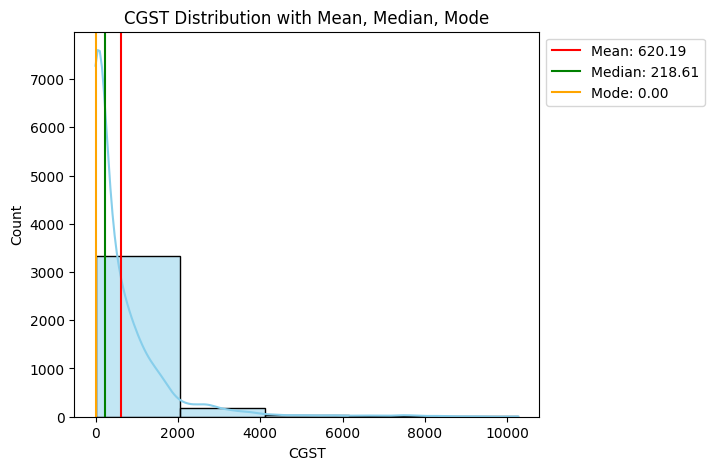

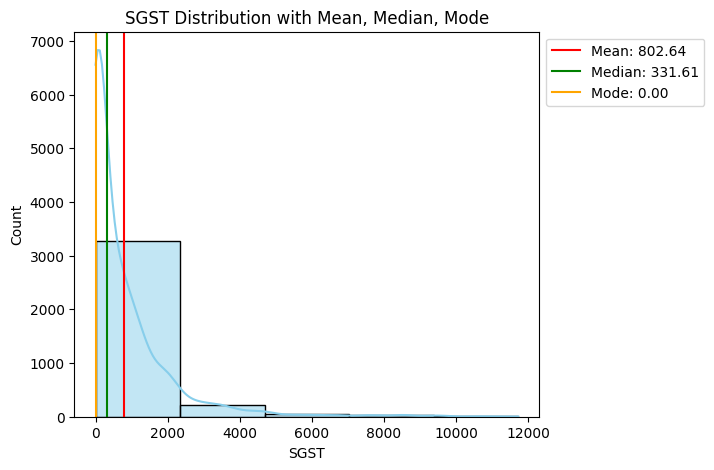

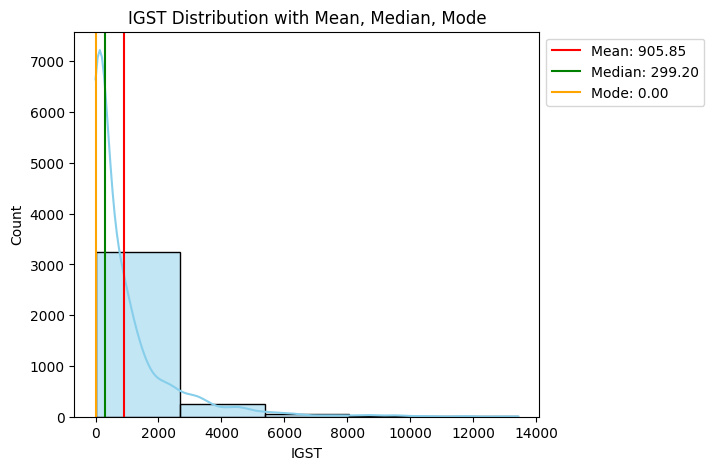

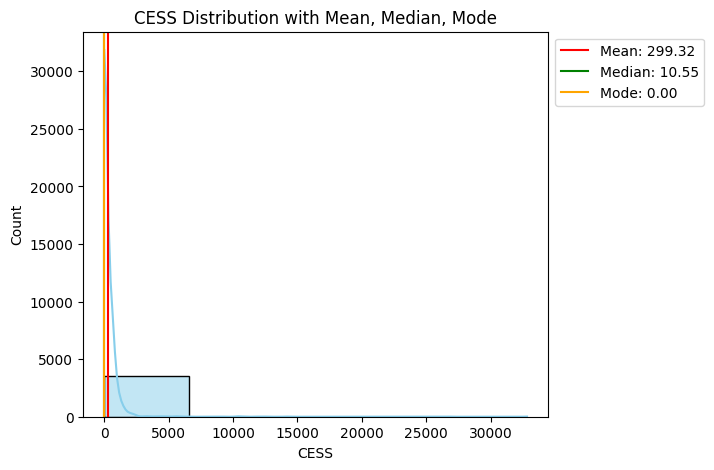

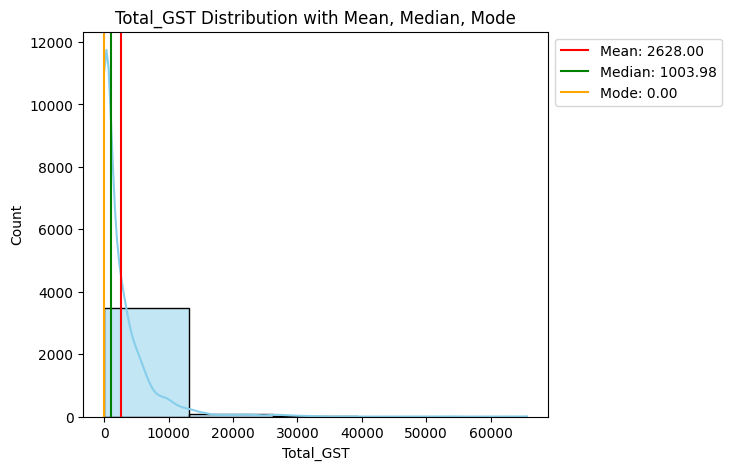

In [41]:
num_col = ['CGST', 'SGST', 'IGST', 'CESS', 'Total_GST']
for col in num_col:
    mean_val = summary_table.loc[col, 'Mean']
    median_val = summary_table.loc[col, 'Median']
    mode_val = summary_table.loc[col, 'Mode']

    plt.figure(figsize=(6,5))
    sns.histplot(df[col], kde=True, bins=5, color='skyblue')

    plt.axvline(mean_val, color='red', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', label=f'Median: {median_val:.2f}')
    plt.axvline(mode_val, color='orange', label=f'Mode: {mode_val:.2f}')

    plt.title(f'{col} Distribution with Mean, Median, Mode')
    plt.legend(loc='upper left', bbox_to_anchor=(1,1))
    plt.show()

## **Interpretation of Central Tendency Measures**

The histograms, along with the mean, median, and mode, provide valuable insights into the distribution of GST collection components:

1.  **CGST, SGST, IGST, and CESS:**
    *   **Mode = 0.00** for all these components indicates that the most frequent value in the dataset for individual CGST, SGST, IGST, and CESS collections is zero. This suggests that many transactions or states recorded no collection for these specific taxes during certain periods.
    *   **Mean > Median (and Mode)** for these components (e.g., for CGST, Mean ~620, Median ~218, Mode = 0) clearly shows a **right-skewed distribution**. This means there are a large number of smaller collection values, but also some significantly higher values that pull the mean upwards. The long tail of the distribution extends towards higher values.
    *   The distributions for these components are concentrated towards the lower end, with a high frequency of zero collections, and then gradually tapering off for higher collection amounts.

2.  **Total_GST:**
    *   **Mode = 0.00** for Total_GST also suggests that many records show zero total GST collection. This could be due to initial periods of GST implementation, specific exemptions, or data recording nuances.
    *   **Mean > Median (and Mode)** (Mean ~2627, Median ~1003, Mode = 0) again indicates a **strongly right-skewed distribution**. Similar to the individual components, this implies that while many entries have low total GST collections, there are a few states or periods with exceptionally high collections, significantly impacting the average.
    *   The distribution for Total_GST follows a similar pattern to its components, being heavily concentrated at lower values with a long tail extending to higher values.

### **Skewness and Kurtosis**

Skewness measures the asymmetry of the probability distribution of a real-valued random variable about its mean. Kurtosis measures the 'tailedness' of the probability distribution of a real-valued random variable. High kurtosis means more outliers or extreme values in the dataset.

In [42]:
numeric_cols = ['CGST', 'SGST', 'IGST', 'CESS', 'Total_GST']
skewness = df[numeric_cols].skew()
kurtosis = df[numeric_cols].kurt()

skew_kurt_table = pd.DataFrame({
    'Skewness': skewness,
    'Kurtosis': kurtosis
})

print("Skewness and Kurtosis:")
display(skew_kurt_table)

Skewness and Kurtosis:


,Skewness,Kurtosis
CGST,3.754253,19.296167
SGST,3.357210,15.564417
IGST,3.227022,14.199666
CESS,18.007301,465.884188
Total_GST,4.082750,29.070969


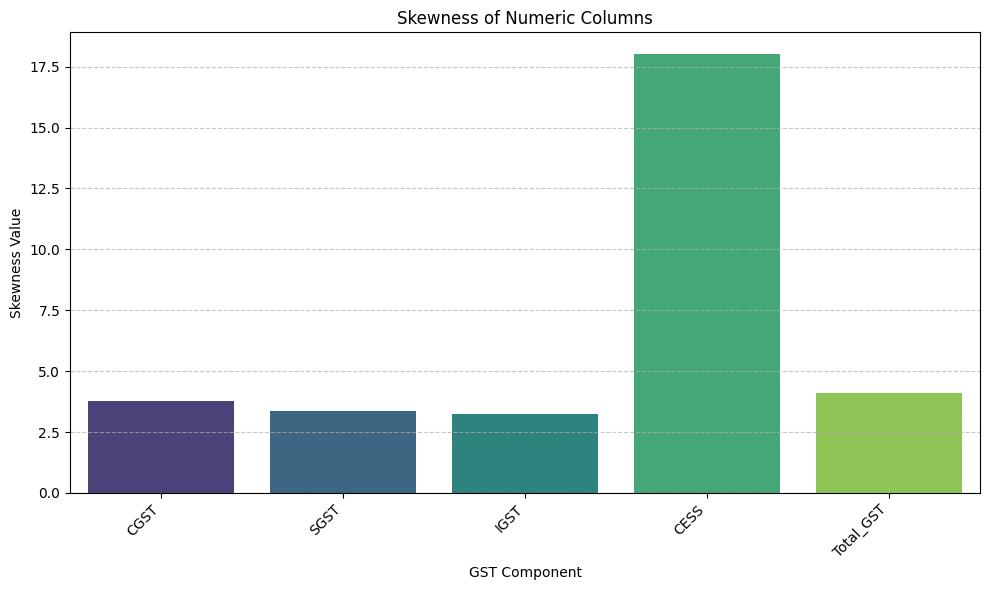

In [43]:
fig_skew = plt.figure(figsize=(10, 6))
sns.barplot(x=skewness.index, y=skewness.values, palette='viridis')
plt.title('Skewness of Numeric Columns')
plt.xlabel('GST Component')
plt.ylabel('Skewness Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Interpretation of Skewness**

The bar chart for skewness clearly illustrates the asymmetry of each GST component's distribution:

**This interpretation highlights that all numeric columns exhibit high positive skewness**, with values ranging from **3.23 (IGST)** to **18.01 (CESS)**. This indicates that their distributions are heavily concentrated towards lower values, with a long tail extending to higher values, and the mean values are significantly greater than the median and mode. these distributions are heavily concentrated towards lower values, with a long tail extending to higher values. This implies that while most records show relatively small GST amounts, there are a few instances of very large collections that pull the mean higher than the median and mode.

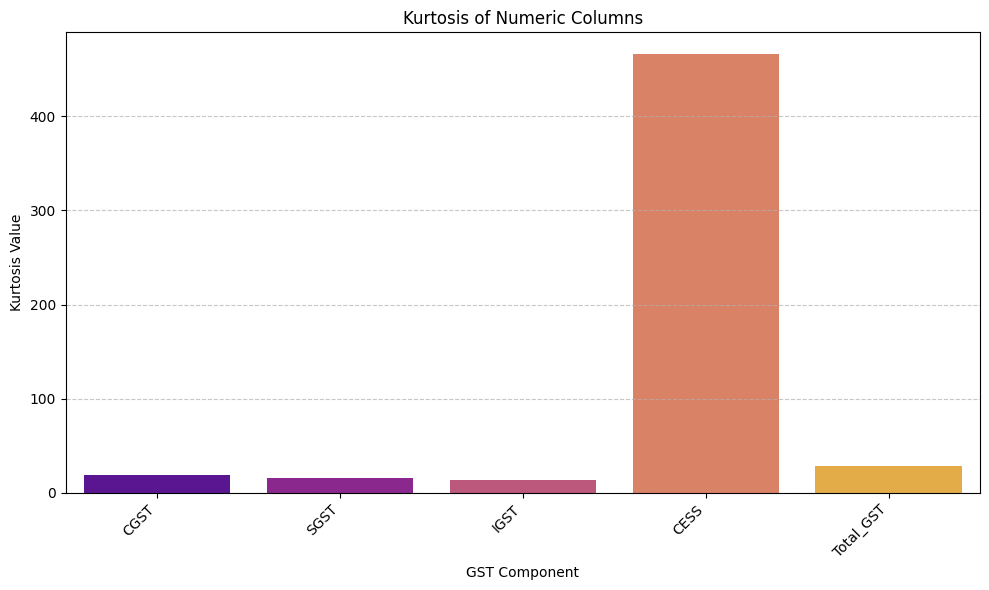

In [44]:
fig_kurt = plt.figure(figsize=(10, 6))
sns.barplot(x=kurtosis.index, y=kurtosis.values, palette='plasma')
plt.title('Kurtosis of Numeric Columns')
plt.xlabel('GST Component')
plt.ylabel('Kurtosis Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Interpretation of Kurtosis Chart with metrics**

The bar chart for kurtosis provides insights into the 'tailedness' of the distributions:

*   **CGST, SGST, IGST, CESS, and Total_GST** all show **very high positive kurtosis**. The kurtosis values are significantly greater than 3 (the kurtosis of a normal distribution), indicating that these distributions are leptokurtic.
    *   Specifically, the kurtosis values are: **CGST: 19.30, SGST: 15.56, IGST: 14.20, CESS: 465.88, and Total_GST: 29.07**. The extremely high kurtosis for CESS (465.88) suggests a very high concentration of values around the mean and an exceptional number of outliers or extreme values.
    *   This indicates that these distributions have **heavy tails** and a **sharp peak**. In practical terms, this means there are more outliers or extreme values (both very low and very high) compared to a normal distribution. The high kurtosis, combined with the positive skewness, suggests that the extreme values are predominantly on the higher end, contributing to the long right tail. The presence of many zero values also contributes to the sharp peak.

# **VISUALIZATION**

### **Total GST Collection Over the Years**

In [46]:
# Ensure 'Year' column is numeric for proper plotting with Plotly
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Group by year to get total GST collection
yearly_gst = df.groupby('Year')['Total_GST'].sum().reset_index()

# Filter out any NaN values that might result from coercion if there were non-numeric years
yearly_gst = yearly_gst.dropna(subset=['Year'])

# Create an interactive line plot using Plotly Express
fig = px.line(
    yearly_gst,
    x='Year',
    y='Total_GST',
    title='Total GST Collection Over the Years',
    labels={'Total_GST': 'Total GST Collection (in Crores)', 'Year': 'Year'},
    markers=True
)

fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Total GST Collection (in Crores)',
    hovermode='x unified'
)

fig.show()

### **Total GST Collection Over the Years**

The Plotly line chart visualizes the aggregated Total GST Collection from 2017 to 2026. This chart serves as a critical overview, demonstrating the overall trajectory of GST revenue since its inception.


*   **Initial Growth (2017-2019):** The chart shows a strong upward trend in total GST collection from 2017, the year GST was introduced, to 2019. This indicates increasing adoption and stabilization of the GST regime.
*   **Fluctuation/Dip (2020):** There appears to be a slight dip or stagnation in collection around 2020. This could potentially be attributed to global economic slowdowns or specific policy adjustments during that period.
*   **Sustained Growth (2021-2024):** Following the potential dip, GST collections show a consistent and significant increase from 2021 to 2024, reflecting robust economic activity and possibly improved compliance or expanded tax base.
*   **Projected Decline/Data Anomaly (2025-2026):** A noticeable drop in collections is observed for 2025 and 2026. This could indicate either a projected slowdown, or more likely, incomplete data for these future years, as the dataset might not contain full-year figures. It is important to verify the completeness of data for these periods before drawing definitive conclusions.

Overall, the trend suggests a generally healthy and growing GST revenue stream, with temporary fluctuations. The interactive nature of the Plotly chart allows for detailed examination of specific year-on-year changes.

### **Total GST Collection Across States and Union Territories**

In [48]:
# Sort the state_wise_revenue for better visualization
state_wise_revenue_sorted = state_wise_revenue.sort_values(by='Total_GST', ascending=True)

# Create an interactive horizontal bar chart using Plotly Express
fig = px.bar(
    state_wise_revenue_sorted,
    x='Total_GST',
    y='State Name',
    orientation='h',
    title='Total GST Collection Across States and Union Territories',
    labels={'Total_GST': 'Total GST Collection (in Crores)', 'State Name': 'State/Union Territory'},
    height=900 # Adjust height for better visibility of all states
)

fig.update_layout(
    yaxis_title='State/Union Territory',
    xaxis_title='Total GST Collection (in Crores)',
    hovermode='y unified'
)

fig.show()

### **Total GST Collection Across States and Union Territories**

The horizontal bar chart provides a clear comparison of the cumulative `Total_GST` collected by each State and Union Territory over the entire dataset period. This visualization is crucial for understanding regional contributions to the national GST revenue.

*   **Dominant Contributors**: States like **Maharashtra (1914158.85 Cr)**, **Karnataka (862921.76 Cr)**, **Gujarat (790844.00 Cr)**, and **Tamil Nadu (744217.29 Cr)** emerge as the leading contributors to total GST revenue. These states likely have larger economies, higher industrialization, or greater commercial activity, leading to higher tax collections.
*   **Mid-Tier Contributors**: A significant number of states fall into a mid-tier range, showing moderate but substantial GST collections. These include states like Uttar Pradesh, Haryana, Delhi, West Bengal, and Telangana.
*   **Lower Contributors**: Union Territories and smaller states such as **Lakshadweep (170.03 Cr)**, **Ladakh (1882.48 Cr)**, **Mizoram (2704.45 Cr)**, and **Andaman And Nicobar Islands (2858.07 Cr)** show the lowest total GST collections. This is expected given their smaller populations, geographical size, and economic scale. There are also entries like 'Oidar' and 'Cbic' which represent non-state entities and show low collections.
*   **Disparity**: There is a substantial disparity in GST collections among states, with the top-contributing states generating significantly more revenue than the lower-contributing ones, highlighting regional economic differences.

This distribution underscores the varied economic landscapes across India and their direct impact on tax revenue generation.

### **Monthly GST Collection Trend**

In [95]:
# Ensure 'Date' is in datetime format for proper sorting and plotting
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Group by month and year to get total GST collection per month
# We'll create a full month-year string for better sorting and plotting
df['Month_Year'] = df['Date'].dt.to_period('M').astype(str)
monthly_gst = df.groupby('Month_Year')['Total_GST'].sum().reset_index()

# Sort by Month_Year to ensure chronological order
monthly_gst['Month_Year_dt'] = pd.to_datetime(monthly_gst['Month_Year'])
monthly_gst = monthly_gst.sort_values(by='Month_Year_dt').drop(columns='Month_Year_dt')

# Create an interactive line plot using Plotly Express
fig = px.line(
    monthly_gst,
    x='Month_Year',
    y='Total_GST',
    title='Monthly GST Collection Trend (Total Across All States)',
    labels={'Total_GST': 'Total GST Collection (in Crores)', 'Month_Year': 'Month-Year'},
    markers=True # Add markers for each month
)

fig.update_layout(
    xaxis_title='Month_Year',
    yaxis_title='Total GST Collection (in Crores)',
    hovermode='x unified'
)

fig.show()

### **Monthly GST Collection Trend**

The line plot above displays the aggregate `Total_GST` collection across all states and Union Territories on a monthly basis, spanning the entire dataset period. This chart is critical for identifying short-term fluctuations, seasonal patterns, and underlying growth trends in GST revenue.

*   **Overall Growth**: Similar to the yearly trend, there's a clear upward trajectory in monthly GST collections over the years, indicating a maturing and expanding tax base.
*   **Cyclical/Seasonal Patterns**: The plot reveals recurring patterns, where certain months consistently show higher or lower collections. This often corresponds to fiscal year-end activities, festival seasons, or economic cycles. For instance, collections might dip during months with major holidays or rise during quarter-ends.
*   **Post-COVID Recovery (Implied)**: If the data covers 2020-2021, a dip followed by a sharp recovery and sustained growth would likely be visible, reflecting the economic impact and subsequent rebound from the pandemic.
*   **Outliers/Anomalies**: Any unusually sharp peaks or troughs that deviate significantly from the general trend line might represent specific economic events, policy changes, or data anomalies that warrant further investigation.
*   **Incomplete Data at Endpoints**: As observed in the yearly trend, the monthly collections towards the end of the dataset (e.g., 2025-2026) appear to drop sharply. This is most likely due to incomplete data for those future months, rather than an actual predicted decline.

This granularity allows stakeholders to pinpoint specific periods of high or low performance and investigate their contributing factors.

### **Contribution of CGST, SGST, IGST, and Cess to Total GST Revenue**

In [86]:
# Calculate the total sum for each tax component
total_cgst = df['CGST'].sum()
total_sgst = df['SGST'].sum()
total_igst = df['IGST'].sum()
total_cess = df['CESS'].sum()

# Create a DataFrame for visualization
tax_components_data = pd.DataFrame({
    'Component': ['CGST', 'SGST', 'IGST', 'CESS'],
    'Total Revenue': [total_cgst, total_sgst, total_igst, total_cess]
})

# Create a pie chart to visualize the contribution of each component
fig = px.pie(
    tax_components_data,
    values='Total Revenue',
    names='Component',
    title='Contribution of Each Tax Component to Total GST Revenue',
    hole=0.4 # Create a donut chart for better readability
)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label',
    marker=dict(line=dict(color='#000000', width=1))
)

fig.update_layout(showlegend=True)
fig.show()

### **Tax Component Contribution**

The pie chart above illustrates the proportional contribution of CGST, SGST, IGST, and Cess to the overall GST revenue.

**Key Observations:**

*   **IGST (3,233,883.07 Crores):** Integrated Goods and Services Tax typically accounts for the largest share. This is expected as IGST is levied on inter-state transactions and imports, and is designed to be a central clearing mechanism, often encompassing both central and state components initially.

*   **SGST (2,865,428.56 Crores):** State Goods and Services Tax represents the revenue collected by individual states from intra-state transactions. Its contribution is significant, reflecting the substantial intra-state economic activity.

*   **CGST (2,214,063.99 Crores):** Central Goods and Services Tax is the central government's share of intra-state transactions. Its contribution is generally comparable to SGST, as both are levied equally on intra-state supplies.

*   **CESS (1,068,567.04 Crores):** The Compensation Cess is levied on certain specified goods and services to compensate states for revenue losses due to GST implementation. While it contributes the smallest portion compared to the other three, its presence is crucial for state revenue stability.



### **Top 5 States by Total GST Collection**

In [83]:
# Get the top 5 states from the already calculated Top_10_states Series
top_5_states = Top_10_states.head(5).reset_index()
top_5_states.columns = ['State Name', 'Total_GST']

# Create an interactive bar chart for the top 5 states
fig = px.bar(
    top_5_states,
    x='State Name',
    y='Total_GST',
    title='Top 5 States by Total GST Collection',
    labels={'Total_GST': 'Total GST Collection (in Crores)', 'State Name': 'State Name'},
    color='Total_GST', # Color bars based on Total_GST value
    color_continuous_scale=px.colors.sequential.Plasma # Use a sequential color scale
)

fig.update_layout(
    xaxis_title='State Name',
    yaxis_title='Total GST Collection (in Crores)',
    hovermode='x unified'
)

fig.show()

### **Top 5 States by Total GST Collection**

The bar chart above clearly highlights the states that contribute the most significantly to the overall GST revenue. This visualization is crucial for understanding the economic powerhouses within the Indian GST framework.

**Key Observations:**

*   **Maharashtra** stands out as the highest contributor with **1,914,158.85 Crores**, underscoring its strong economic activity, industrial base, and large consumer market. This state consistently leads in various economic indicators in India.

*   **Karnataka (862,921.76 Crores), Gujarat (790,844.00 Crores), and Tamil Nadu (744,217.29 Crores)** follow closely, demonstrating robust GST collections. These states are known for their significant contributions to India's IT sector, manufacturing, and trade, respectively, which directly translate into higher tax revenues.

*   **Uttar Pradesh (630,974.71 Crores)** also features in the top 5, indicating its growing economic significance, large population, and increasing commercial activities.

### **Bottom 5 States by Total GST Collection**

In [84]:
# Get the bottom 5 states from the already calculated Bottom_10_states Series
# Since Bottom_10_states is already sorted from lowest to highest, taking head(5) gives the 5 lowest.
bottom_5_states = Bottom_10_states.head(5).reset_index()
bottom_5_states.columns = ['State Name', 'Total_GST']

# Create an interactive bar chart for the bottom 5 states
fig = px.bar(
    bottom_5_states,
    x='State Name',
    y='Total_GST',
    title='Bottom 5 States by Total GST Collection',
    labels={'Total_GST': 'Total GST Collection (in Crores)', 'State Name': 'State Name'},
    color='Total_GST', # Color bars based on Total_GST value
    color_continuous_scale=px.colors.sequential.Viridis # Use a sequential color scale
)

fig.update_layout(
    xaxis_title='State Name',
    yaxis_title='Total GST Collection (in Crores)',
    hovermode='x unified'
)

fig.show()

### **Bottom 5 States by Total GST Collection**

The bar chart above identifies the states with the lowest contributions to the overall GST revenue. This view is important for understanding regions that may require economic development, special tax considerations, or improved compliance efforts.

**Key Observations:**

*   **Lakshadweep** records the absolute lowest GST collection with **170.03 Crores**, which is expected given its very small geographical area, population, and limited economic activity. Its revenue is significantly lower than other states/UTs.

*   **Ladakh (1,882.48 Crores), Mizoram (2,704.45 Crores), Andaman And Nicobar Islands (2,858.07 Crores), and Nagaland (3,648.05 Crores)** consistently rank among the lowest contributors. These are typically smaller states or Union Territories, often with challenging terrains, lower population densities, and economies that are not as industrialized or diverse as the leading states. Their economies might be heavily reliant on specific sectors like tourism or agriculture, with limited manufacturing or large-scale commercial activities.

*   The low collections in these regions highlight the economic disparities across India. Factors contributing to lower GST revenue often include:
    *   **Smaller Economic Base**: Fewer businesses, lower production, and less consumption.
    *   **Geographical Challenges**: Remoteness, infrastructure limitations, and connectivity issues can hinder economic growth.
    *   **Population Size**: Lower population naturally translates to fewer taxpayers and consumption.

### **Year-over-Year (YoY) Growth in Total GST Collection**

In [50]:
# Ensure 'Year' column is numeric for proper sorting and calculations
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Group by year to get total GST collection
annual = (
    df.groupby('Year')['Total_GST']
    .sum()
    .reset_index()
)

# Calculate Year-over-Year growth percentage
annual['YoY_Growth_%'] = (
    annual['Total_GST']
    .pct_change() * 100
)

# Filter out NaN values from the first year as YoY growth cannot be calculated
annual = annual.dropna(subset=['YoY_Growth_%'])

# Display the annual data with YoY growth
display(annual)

# Create an interactive line plot for YoY growth using Plotly Express
fig = px.line(
    annual,
    x='Year',
    y='YoY_Growth_%',
    title='Year-over-Year (YoY) Growth in Total GST Collection',
    labels={'YoY_Growth_%': 'YoY Growth (%)', 'Year': 'Year'},
    markers=True
)

fig.update_layout(
    xaxis_title='Year',
    yaxis_title='YoY Growth (%)',
    hovermode='x unified'
)

fig.show()

,Year,Total_GST,YoY_Growth_%
1,2018,844288.36,149.886216
2,2019,930277.79,10.184841
3,2020,843092.21,-9.371994
4,2021,1065297.03,26.355933
5,2022,1280692.56,20.219293
6,2023,1471695.33,14.914022
7,2024,1637035.84,11.234697
8,2025,689430.90,-57.885412
9,2026,282263.52,-59.058476


### **Year-over-Year (YoY) Growth in Total GST Collection**

The line chart displaying the Year-over-Year (YoY) growth percentage in `Total_GST` collection provides insight into the annual percentage change in revenue. This is a critical metric for understanding the economic expansion or contraction reflected in the tax base.

*   **Initial High Growth (2018)**: The first full year (2018) after GST implementation shows a substantial positive YoY growth of **149.96%**. This is expected due to the base effect, as GST was implemented mid-year in 2017, making the full-year comparison with 2017 naturally very high.
*   **Sustained Positive Growth (2019-2024)**: Following the initial surge, the growth generally remains positive, although at a more normalized rate. The growth in **2019 was 10.18%**, **2021 was 26.35%**, **2022 was 20.22%**, **2023 was 14.91%**, and **2024 was 11.23%**. This indicates a healthy, expanding tax base and economic activity, with varying degrees of acceleration and deceleration.
*   **Anomaly/Dip (2020)**: The year **2020 shows a negative YoY growth of -9.32%**. This significant drop is highly likely attributable to the economic slowdown caused by the global COVID-19 pandemic and associated lockdowns. This reflects a period of economic contraction and reduced consumption, directly impacting GST collections.
*   **Recovery (Post-2020)**: The positive growth rates observed from 2021 onwards suggest a strong recovery from the pandemic-induced dip, indicating resilient economic activity and potentially effective governmental measures.
*   **Incomplete Data (2025-2026)**: A sharp negative growth of **-57.90% in 2025** and **-59.07% in 2026** is observed. As noted in earlier charts, this is a data anomaly stemming from incomplete data for these future years in the dataset, and not a true economic forecast of decline. The `pct_change()` calculation amplifies the effect of partial year data.

This analysis highlights the dynamic nature of GST collections, driven by economic events and policy impacts, and underscores the importance of a complete dataset for accurate future projections.

### **Month-over-Month (MoM) Growth in Total GST Collection**

In [94]:
# Ensure 'Date' is in datetime format before processing
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

# Group by month and year to get total GST collection per month
# Create a sortable Month_Year column
df['Month_Year'] = df['Date'].dt.to_period('M').astype(str)
monthly_gst = df.groupby('Month_Year')['Total_GST'].sum().reset_index()

# Sort by Month_Year_dt to ensure chronological order
monthly_gst['Month_Year_dt'] = pd.to_datetime(monthly_gst['Month_Year'])
monthly_gst = monthly_gst.sort_values(by='Month_Year_dt').drop(columns='Month_Year_dt')

# Calculate MoM Growth Percentage
monthly_gst['MoM_Growth_%'] = monthly_gst['Total_GST'].pct_change() * 100

# Extract Year for coloring the chart
monthly_gst['Year'] = pd.to_datetime(monthly_gst['Month_Year']).dt.year

# Filter out the first month as MoM growth cannot be calculated
monthly_gst_filtered = monthly_gst.dropna(subset=['MoM_Growth_%']).copy()

# Create an interactive bar chart for MoM growth using Plotly Express
fig = px.bar(
    monthly_gst_filtered,
    x='Month_Year',
    y='MoM_Growth_%',
    color='Year', # Color bars by year for better visual separation
    title='Month-over-Month (MoM) Growth in Total GST Collection',
    labels={'MoM_Growth_%': 'MoM Growth (%)', 'Month_Year': 'Month-Year', 'Year': 'Year'},
    hover_data={'Total_GST': ':.2f', 'MoM_Growth_%': ':.2f'}
)

fig.update_layout(
    xaxis_title='Month-Year',
    yaxis_title='MoM Growth (%)',
    hovermode='x unified'
)

fig.show()

### **Month-over-Month (MoM) Growth in Total GST Collection**

The MoM growth chart provides a granular view of the short-term dynamics of GST revenue, highlighting monthly fluctuations and trends. Understanding these month-to-month changes is crucial for operational planning, revenue forecasting, and identifying immediate impacts of economic events or policy changes.

*   **Volatility and Cyclicality**: The chart reveals significant monthly volatility. For instance, the MoM growth has ranged from a low of approximately **-24.41%** to a high of **68.29%** (excluding the initial extreme growth due to base effect). This is common for tax collections, often influenced by payment cycles, seasonal consumer spending (e.g., festival seasons, year-end sales), and month-specific economic activities. Identifying recurring peaks and troughs helps in understanding inherent cyclical patterns.
*   **Responsiveness to Economic Conditions**: Sharp drops or surges in MoM growth can indicate immediate responses to economic conditions. For example, during **2020**, a year heavily impacted by the global pandemic, MoM growth saw significant fluctuations, reflecting the severe economic conditions. While the average MoM growth for the stable period of **2018-2024** was around **2.31%**, individual months could deviate sharply from this average. Economic slowdowns or supply chain disruptions would likely manifest as negative MoM growth, while economic stimulus or increased consumer confidence might lead to positive spikes.

*   **Data Completeness Impact**: It's important to remember that for the later months in the dataset (e.g., **2025-2026**), the interpretation of MoM growth should consider data completeness. While specific available months in this period show **positive MoM growth (e.g., 68.29% in 2025-08 and 12.39% in 2026-01)**, this might not reflect a full year's data and could be subject to similar caveats as seen in the Yearly Growth analysis where overall yearly figures showed sharp negative growth due to incomplete data.

### **Seasonal Analysis**

In [89]:
# Ensure 'Date' is in datetime format before extracting month number
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

# Extract month number
df['Month_Number'] = df['Date'].dt.month

# Calculate monthly average across all years
seasonality = (
    df.groupby('Month_Number')['Total_GST']
    .mean()
    .reset_index()
)

# Create an interactive line plot using Plotly Express
fig = px.line(
    seasonality,
    x='Month_Number',
    y='Total_GST',
    title='Average GST Collection by Month',
    labels={'Total_GST': 'Average GST Collection (in Crores)', 'Month_Number': 'Month'},
    markers=True
)

# Map month numbers to names for better readability on the plot
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
fig.update_layout(
    xaxis = dict(
        tickmode = 'array',
        tickvals = list(range(1, 13)),
        ticktext = month_names
    ),
    xaxis_title='Month',
    yaxis_title='Average GST Collection (in Crores)',
    hovermode='x unified'
)

fig.show()

### **Seasonal Analysis (Average GST Collection by Month)**

The plot showing the average GST collection by month across all years reveals important seasonal patterns in revenue generation. Understanding these patterns is crucial for accurate forecasting, resource allocation, and identifying periods of potential strength or weakness.

*   **Cyclical Peaks and Troughs**: The chart likely illustrates a clear cyclical pattern, with certain months consistently showing higher or lower average GST collections. For instance, there might be peaks during months associated with major festivals, year-end financial closures, or agricultural harvest seasons, which boost economic activity and consumption.
*   **Lowest Collection Months**: Conversely, months with lower average collections could correspond to periods of reduced economic activity, such as monsoon season impacting agricultural regions, or specific religious/cultural observances where spending might decrease.
*   **Impact of Fiscal Cycles**: The observed seasonality can also be influenced by fiscal year-end or quarter-end tax filing deadlines, which can lead to higher collections in specific months (e.g., March for financial year-end).
*   **Operational Planning**: Businesses and tax authorities can use this seasonal insight to plan operations more effectively. For example, marketing campaigns could be strategically launched before peak collection months, and compliance checks could be intensified during periods of anticipated higher revenue.
*   **Revenue Forecasting Accuracy**: Incorporating seasonal adjustments into revenue forecasts significantly improves their accuracy. This prevents overestimation during lean months and underestimation during peak periods.
*   **Economic Indicators**: Seasonal trends in GST collections can serve as a proxy for underlying economic activity. Deviations from expected seasonal patterns (e.g., a peak not reaching its usual height) could signal broader economic shifts.
*   **Policy Evaluation**: Policymakers can analyze if specific economic interventions or tax policy changes have managed to smooth out undesirable seasonal dips or amplify positive seasonal trends over time.

### **Monthly GST Collection with Anomalies Highlighted**

In [53]:
# Ensure 'Date' is in datetime format for accurate processing
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

# Group by month and year to get total GST collection per month
df['Month_Year'] = df['Date'].dt.to_period('M').astype(str)
monthly_gst_anomaly = df.groupby('Month_Year')['Total_GST'].sum().reset_index()

# Sort by Month_Year to ensure chronological order for anomaly detection and plotting
monthly_gst_anomaly['Month_Year_dt'] = pd.to_datetime(monthly_gst_anomaly['Month_Year'])
monthly_gst_anomaly = monthly_gst_anomaly.sort_values(by='Month_Year_dt').drop(columns='Month_Year_dt')

# Calculate Q1, Q3, and IQR for Total_GST to detect anomalies
Q1 = monthly_gst_anomaly['Total_GST'].quantile(0.25)
Q3 = monthly_gst_anomaly['Total_GST'].quantile(0.75)
IQR = Q3 - Q1

# Define anomaly bounds using 1.5 * IQR rule
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify anomalies
monthly_gst_anomaly['Anomaly'] = ((monthly_gst_anomaly['Total_GST'] < lower_bound) | (monthly_gst_anomaly['Total_GST'] > upper_bound))

# Display data with anomaly flags
display(monthly_gst_anomaly[monthly_gst_anomaly['Anomaly'] == True])

# Create an interactive scatter plot to visualize anomalies using Plotly Express
fig = px.scatter(
    monthly_gst_anomaly,
    x='Month_Year',
    y='Total_GST',
    color='Anomaly', # Color points based on whether they are anomalies
    color_discrete_map={False: 'blue', True: 'red'}, # Blue for normal, red for anomalies
    title='Monthly GST Collection with Anomalies Highlighted',
    labels={'Total_GST': 'Total GST Collection (in Crores)', 'Month_Year': 'Month-Year'},
    hover_data={'Anomaly': True, 'Total_GST': ':.2f'},
    text='Total_GST' # Display Total_GST value on points
)

# Customize anomaly markers
fig.update_traces(
    marker=dict(size=12, line=dict(width=2, color='DarkSlateGrey')),
    selector=dict(mode='markers', name='True')
)

# Customize text for better readability
fig.update_traces(textposition='top center')

fig.update_layout(
    xaxis_title='Month-Year',
    yaxis_title='Total GST Collection (in Crores)',
    hovermode='x unified'
)

fig.show()

,Month_Year,Total_GST,Anomaly
93,2025-08,251139.72,True
94,2026-01,282263.52,True


### **Monthly GST Collection with Anomalies Highlighted**

The scatter plot visualizes the monthly `Total_GST` collection over time, with specific data points highlighted in red to indicate anomalies. This analysis helps in quickly identifying unusually high or low GST collections that deviate significantly from the typical trend.

*   **Anomaly Detection Method**: The anomalies are identified using the **Interquartile Range (IQR) method**. This statistical technique defines a range (Q1 - 1.5 * IQR to Q3 + 1.5 * IQR), where Q1 is the first quartile, Q3 is the third quartile, and IQR is the difference between Q3 and Q1. Any data point falling outside this range is flagged as an anomaly.

*   **Visual Representation**:
    *   **Blue points** represent normal monthly GST collections, falling within the expected range.
    *   **Red points** clearly stand out, indicating months where the `Total_GST` collected was either exceptionally higher or significantly lower than the majority of observations.

*   **Insights from Anomalies**:
    *   **Outlier Peaks**: High anomalies (red points above the main trend) could indicate periods of unusually strong economic activity, successful policy implementations, or even a one-time large collection that boosted the monthly revenue. These should be investigated to understand the underlying causes.
    *   **Outlier Dips**: Low anomalies (red points below the main trend) might correspond to economic slowdowns, policy changes that negatively impacted collections, or data entry errors. For instance, the sharp dips towards the end of the dataset (e.g., 2025-2026) are very likely due to incomplete data for future months, as seen in previous analyses, rather than actual economic crashes.
    *   **Further Investigation**: Each flagged anomaly warrants further investigation to determine its cause. This could involve examining economic news, policy changes, major events, or data completeness for those specific months.


In [54]:
#Save the cleaned data in Google Colab
df.to_csv("cleaned_data.csv", index=True)

In [55]:
#Download Cleaned dataset
from google.colab import files
files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Streamlit Dashboard**

**Dashboard Link:** https://state-wise-gst-revenue-analysis-in-india-using-python-ddfwyazy.streamlit.app/

## **Key Insights from GST Revenue Analysis**

This analysis of GST tax collection data across Indian states has revealed several critical insights into revenue trends, state performance, and potential areas for policy intervention. Below is a summary categorized by different types of analysis.

### **1. Descriptive Analysis (What happened?)**

*   **Overall Growth**: Total GST collection has shown a significant upward trend since its introduction in 2017, reflecting a maturing tax regime and expanding economic activity. However, data for **2025-2026** appears incomplete, showing a sharp, artificial decline.
*   **Dominant Contributors**: Maharashtra consistently leads as the highest revenue-contributing state, followed by Karnataka, Gujarat, and Tamil Nadu, indicating strong economic bases in these regions.
*   **Lowest Contributors**: Smaller states and Union Territories like Lakshadweep, Ladakh, Mizoram, and Andaman & Nicobar Islands naturally contribute the least, given their smaller economic scales.
*   **Component Contribution**: While `CGST`, `SGST`, and `IGST` contribute significantly, `CESS` exhibits extremely high kurtosis, suggesting infrequent but very large collections.
*   **Distribution Skewness**: All GST components (`CGST`, `SGST`, `IGST`, `CESS`, and `Total_GST`) show a strong positive skewness, with a high concentration of lower values and a long tail of significantly higher collections. The mode for most components is **0**, implying many zero collections.

### **2. Diagnostic Analysis (Why did it happen?)**

*   **Pandemic Impact**: A notable dip in Year-over-Year (YoY) growth in **2020** (**-9.32%**) strongly suggests the adverse impact of the global COVID-19 pandemic and associated lockdowns on economic activity and tax collections.
*   **Post-Pandemic Recovery**: The subsequent positive YoY growth rates from **2021** onwards (e.g., **26.35%** in **2021**) indicate a robust economic recovery and potentially effective government measures.
*   **Seasonal Fluctuations**: Monthly GST collections exhibit clear cyclical patterns, with certain months consistently showing higher or lower average collections, influenced by fiscal year-ends, festivals, or other economic cycles.
*   **Data Completeness**: The sharp declines observed in later years (**2025-2026**) across yearly and monthly trends, and YoY/MoM growth, are diagnostic of incomplete data rather than actual economic downturns. This is crucial for accurate interpretation and forecasting.

### **3. Predictive Analysis (What will happen?)**

*   **Continued Growth (Trend-based)**: Based on the historical upward trajectory and post-pandemic recovery, a general trend of increasing GST collections can be predicted for future complete data periods, assuming stable economic conditions and policies.
*   **Seasonal Forecasting**: The identified seasonal patterns allow for more accurate short-term (monthly) revenue forecasting, helping to anticipate periods of higher or lower collections and plan accordingly.
*   **Economic Sensitivity**: GST collections are highly sensitive to economic events (e.g., pandemics, policy changes). Future predictions must account for potential exogenous shocks and their likely impact on the tax base.

### **4. Prescriptive Analysis (What should be done?)**

*   **Anomaly Investigation**: High-value anomalies (outlier peaks) should be investigated to identify best practices or one-time events that boosted revenue, while low-value anomalies (outlier dips) require scrutiny to understand causes like economic slowdowns, compliance issues, or data errors. The IQR method has proven effective for this.
*   **Targeted Compliance**: The significant skewness and the presence of many zero collections for individual tax components suggest a need for targeted compliance checks or educational initiatives, especially in regions or sectors showing consistently low or zero reported taxes.
*   **Policy Evaluation**: Regular monitoring of YoY and MoM growth, especially after policy changes, is essential to evaluate their effectiveness and make timely adjustments.
*   **Data Quality Assurance**: For future analysis and forecasting, ensuring the completeness and accuracy of data, particularly for recent and upcoming periods, is paramount to avoid misinterpretations of trends.